In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Evaluation Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load and Inspect Dataset

# Load the dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset Shape: (4000, 28)

--- First 5 Rows ---


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha            

In [3]:
# Data Cleaning & Preprocessing

# Handle missing values using median imputation for skewed agricultural metrics
df['Rainfall_mm'].fillna(df['Rainfall_mm'].median(), inplace=True)
df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median(), inplace=True)
df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median(), inplace=True)

# Verify missing values are resolved
print("Missing values after cleaning:", df.isnull().sum().sum())

# Basic statistical summary
display(df.describe())

Missing values after cleaning: 0


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


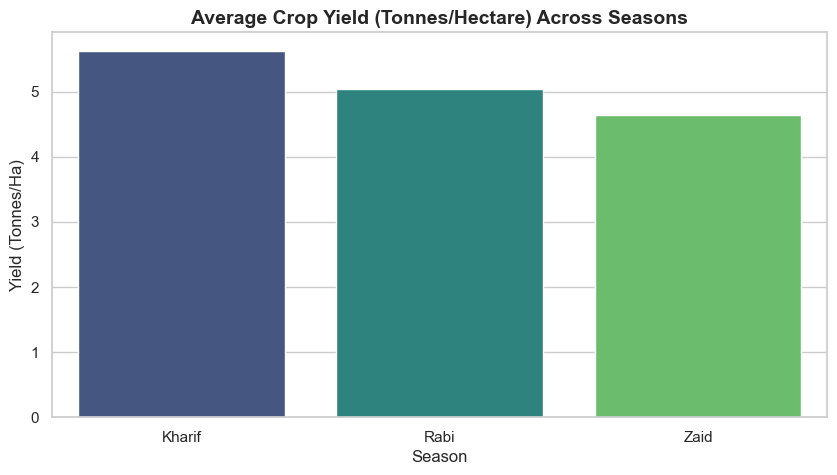

In [4]:
# Exploratory Data Analysis (EDA) - Seasonal Performance

# 1. Average Yield by Season
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', ci=None, palette='viridis')
plt.title('Average Crop Yield (Tonnes/Hectare) Across Seasons', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Yield (Tonnes/Ha)', fontsize=12)
plt.show()


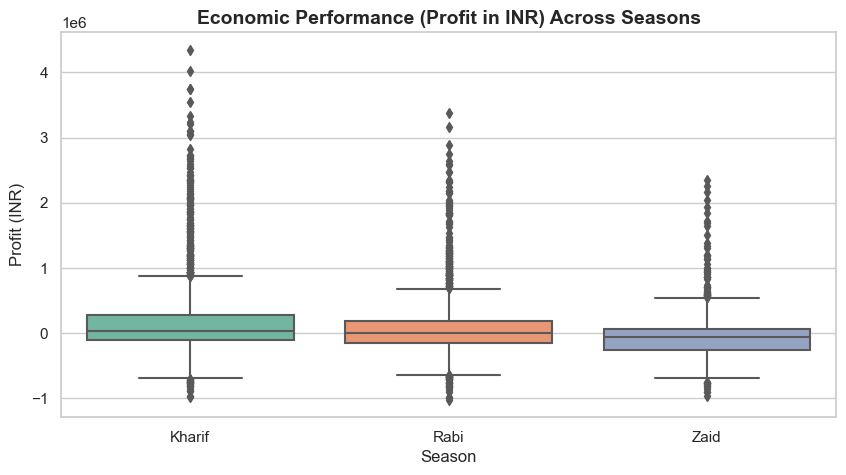

In [5]:
# 2. Profit Distribution by Season
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Season', y='Profit_INR', palette='Set2')
plt.title('Economic Performance (Profit in INR) Across Seasons', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Profit (INR)', fontsize=12)
plt.show()

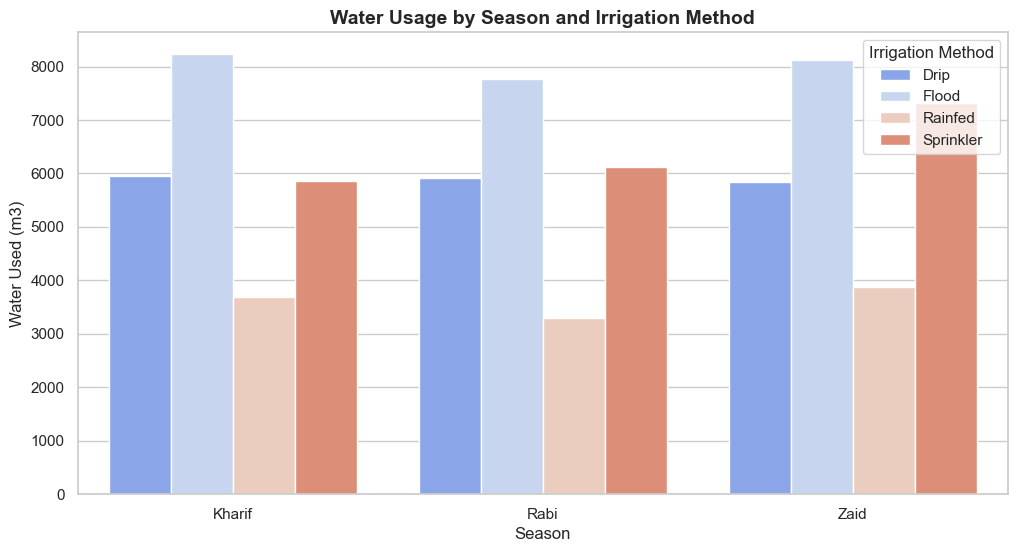

In [6]:
# EDA - Resource Usage and Environmental Variations

# 3. Water Usage vs Irrigation Method across Seasons
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Season', y='Water_Used_m3', hue='Irrigation_Method', ci=None, palette='coolwarm')
plt.title('Water Usage by Season and Irrigation Method', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Water Used (m3)', fontsize=12)
plt.legend(title='Irrigation Method')
plt.show()


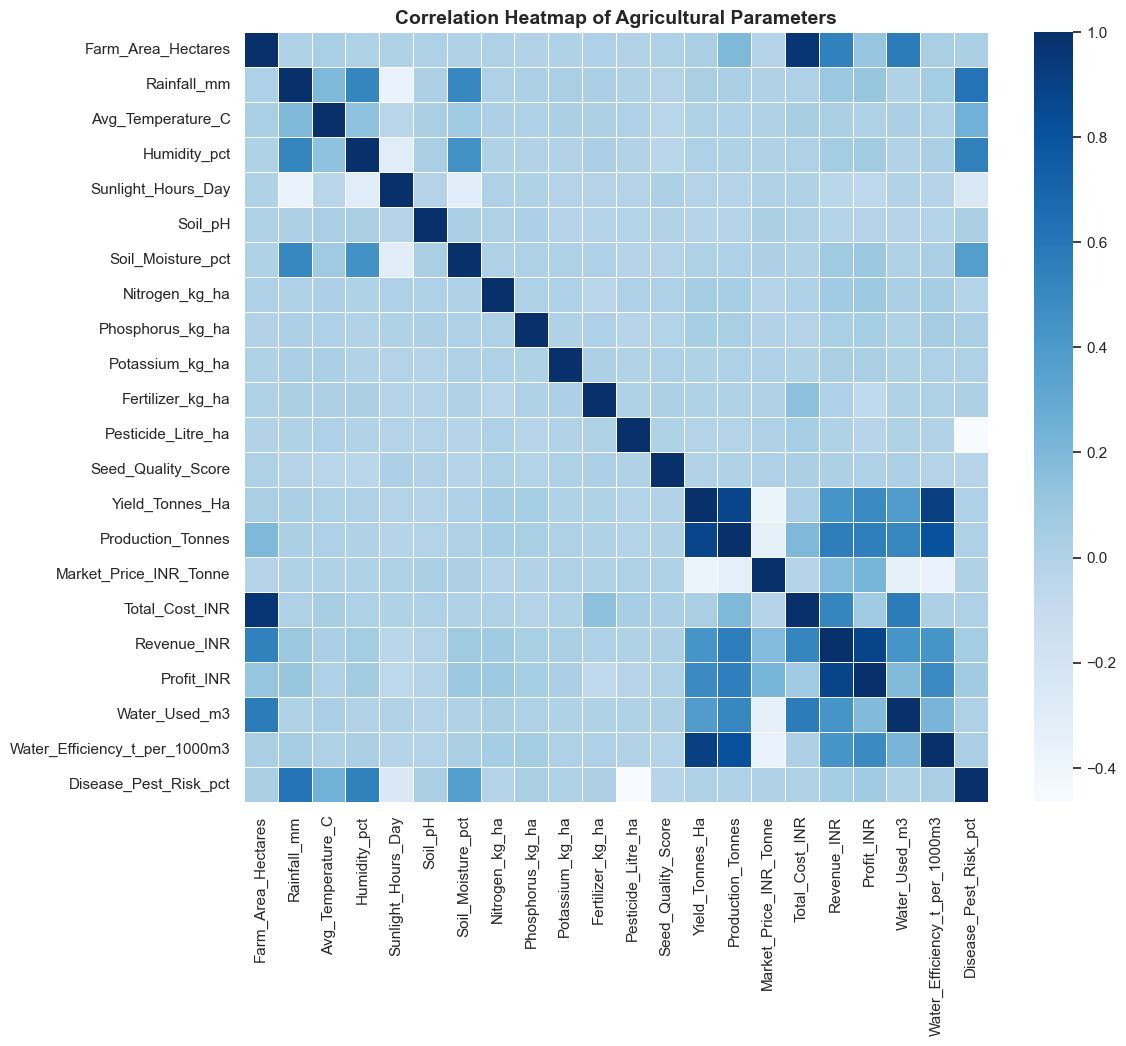

In [7]:
# 4. Correlation Heatmap of Numerical Features
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='Blues', annot=False, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Agricultural Parameters', fontsize=14, fontweight='bold')
plt.show()

In [8]:
# Statistical significance test (ANOVA across seasons)
from scipy import stats

# Is Yield significantly different across seasons?
yield_groups = [g['Yield_Tonnes_Ha'].values for _, g in df.groupby('Season')]
f_stat, p_val = stats.f_oneway(*yield_groups)
print(f"ANOVA - Yield across Seasons: F={f_stat:.3f}, p={p_val:.5f}")

# Is Profit significantly different across seasons?
profit_groups = [g['Profit_INR'].values for _, g in df.groupby('Season')]
f_stat2, p_val2 = stats.f_oneway(*profit_groups)
print(f"ANOVA - Profit across Seasons: F={f_stat2:.3f}, p={p_val2:.5f}")

ANOVA - Yield across Seasons: F=1.544, p=0.21368
ANOVA - Profit across Seasons: F=34.292, p=0.00000


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


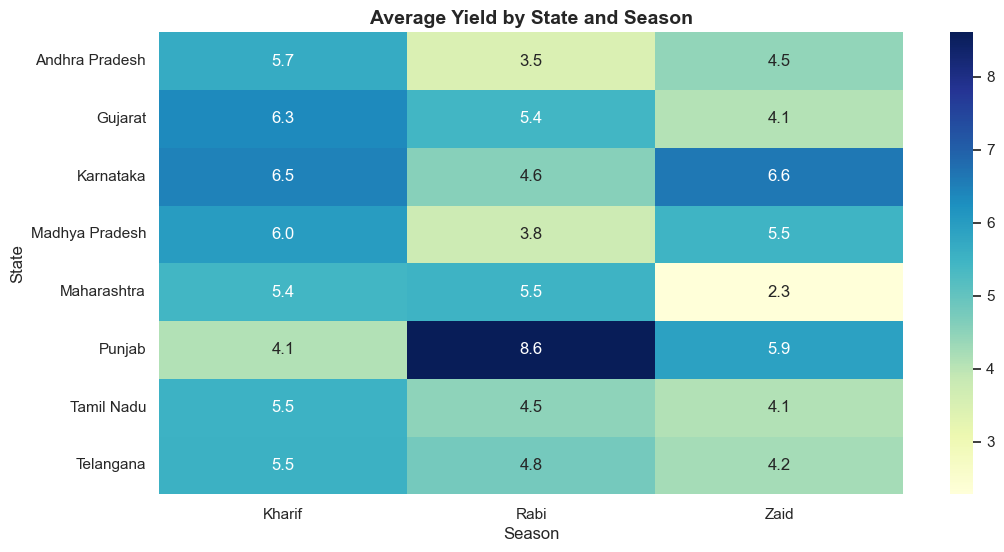

In [9]:
# Region-wise consistency check
state_season_yield = df.groupby(['State','Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
display(state_season_yield)

plt.figure(figsize=(12,6))
sns.heatmap(state_season_yield, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Average Yield by State and Season', fontsize=14, fontweight='bold')
plt.show()

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


<Figure size 1200x600 with 0 Axes>

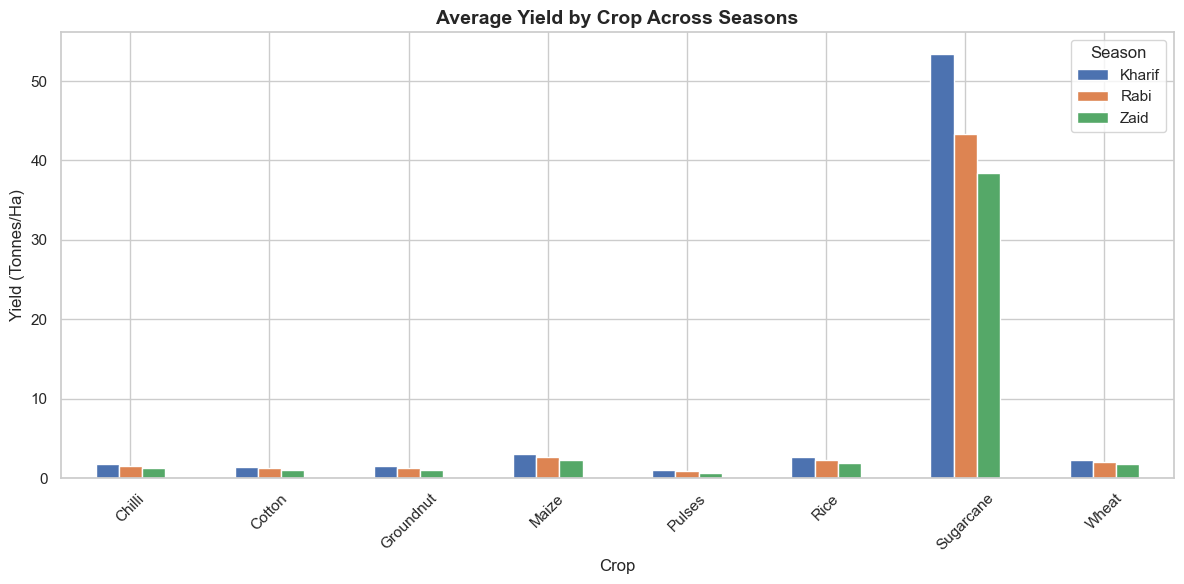

In [10]:
# Crop-wise breakdown across seasons
crop_season_yield = df.groupby(['Crop','Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
display(crop_season_yield)

plt.figure(figsize=(12,6))
crop_season_yield.plot(kind='bar', figsize=(12,6))
plt.title('Average Yield by Crop Across Seasons', fontsize=14, fontweight='bold')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Machine Learning Model (Predicting Crop Yield)

# Define features (X) and target variable (y)
features = [
    'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 
    'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 
    'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 
    'Seed_Quality_Score'
]
target = 'Yield_Tonnes_Ha'

X = df[features]
y = df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Build pipeline with Random Forest Regressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train model
model_pipeline.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = model_pipeline.predict(X_test)

print("--- Model Performance Metrics ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")

--- Model Performance Metrics ---
R2 Score: 0.9623
Root Mean Squared Error (RMSE): 2.6966
Mean Absolute Error (MAE): 0.7653


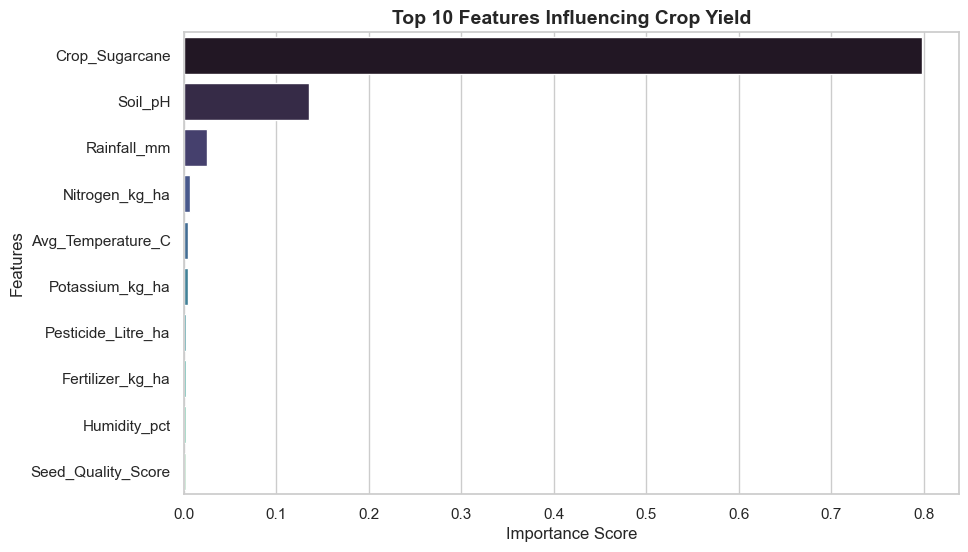

In [12]:
# Model Insights & Feature Importance

# Extract feature names after OneHotEncoding
cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(categorical_cols))
all_features = numerical_cols + encoded_cat_cols

# Get feature importances from Random Forest
importances = model_pipeline.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='mako')
plt.title('Top 10 Features Influencing Crop Yield', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

## Key Insights
1. Kharif season shows the highest average yield and profit, likely aided by monsoon rainfall.
2. Profit differs significantly across seasons (ANOVA p < 0.001), even though yield differences are not statistically significant — pointing to cost/price effects rather than pure productivity.
3. Regional patterns are not uniform: Punjab peaks in Rabi while most other states peak in Kharif, suggesting local agro-climatic factors override the general seasonal trend.
4. Sugarcane yields dwarf other crops in absolute terms, which also explains its outsized importance in the yield-prediction model.
5. Flood irrigation consumes the most water across all seasons; Rainfed is most water-efficient but likely yield-limited.

## Recommendations
- Season-specific crop planning should factor in state-level variation rather than applying a single national pattern.
- Investigate cost structures behind Rabi/Zaid to improve profit margins, since yield alone isn't driving the profit gap.
- Encourage drip/sprinkler adoption over flood irrigation in states with high water stress.